# Machine Learning 2 - Neural Networks

In this lab, we will use simple Neural Networks to classify the images from the simplified CIFAR-10 dataset. We will compare our results with those obtained with Decision Trees and Random Forests.

Lab objectives
----
* Classification with neural networks
* Influence of hidden layers and of the selected features on the classifier results

In [5]:
from lab_tools import CIFAR10, evaluate_classifier, get_hog_image

dataset = CIFAR10("C:/Users/regna/Documents/ULB/MA2/Q2/INFO_H501/INFO_H501/docs/LABS/CIFAR10/")

Pre-loading training data
Pre-loading test data


We will use the *[Multi-Layer Perceptron](http://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html#sklearn.neural_network.MLPClassifier)* implementation from scikit-learn, which is only available since version 0.18. You can check which version of scikit-learn is installed by executing this :

In [6]:
import sklearn
print(sklearn.__version__)

1.9.0


If you have version 0.17 or older, please update your scikit-learn installation (for instance, with the command *pip install scikit-learn==0.19.1* in the terminal or Anaconda prompt)

## Build a simple neural network

* Using the [MLPClassifier](http://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html) from scikit-learn, create a neural network with a single hidden layer.
* Train this network on the CIFAR dataset.
* Using cross-validation, try to find the best possible parameters.

In [30]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

In [19]:
kf = StratifiedKFold(5)

cms=[]
accs= []

for train,test in kf.split(dataset.train['hog'], dataset.train['labels']):
    train_x = dataset.train['hog'][train]
    train_y = dataset.train['labels'][train]
    clf = MLPClassifier(hidden_layer_sizes=(100,), alpha=1e-4, verbose=False ,
                    learning_rate_init=0.01, early_stopping=True)
    clf.fit(train_x, train_y)
    test_x = dataset.train['hog'][test]
    test_y = dataset.train['labels'][test]
    pred = clf.predict(test_x)
    cms.append(confusion_matrix(test_y, pred))
    accs.append((accuracy_score(test_y, pred)))
    break

In [20]:
for cm, acc in zip(cms, accs):
    print('---')
    print(cm)
    print(f"Accuracy {acc:.2f}")

---
[[815 124  61]
 [116 709 175]
 [ 36  97 867]]
Accuracy 0.80


In [21]:
print(dataset.labels)

['Airplane', 'Bird', 'Horse']


On peut aussi récupérer les poids des connexions dans le network:

In [23]:
print(clf.coefs_[0].shape) #weigth between input and hidden layer
print(clf.coefs_[1].shape) #weigth between hidden and output layer

(256, 100)
(100, 3)


En effet, l'input sont les Hog de taille 256, on a 100 neurones danbs la hidden layer et 3 classes à déterminer donc 3 sorties. Pour chacun des 100 neurones , on peut prendre la valeur absolue du maximum des trois connections (pour les trois output layers)

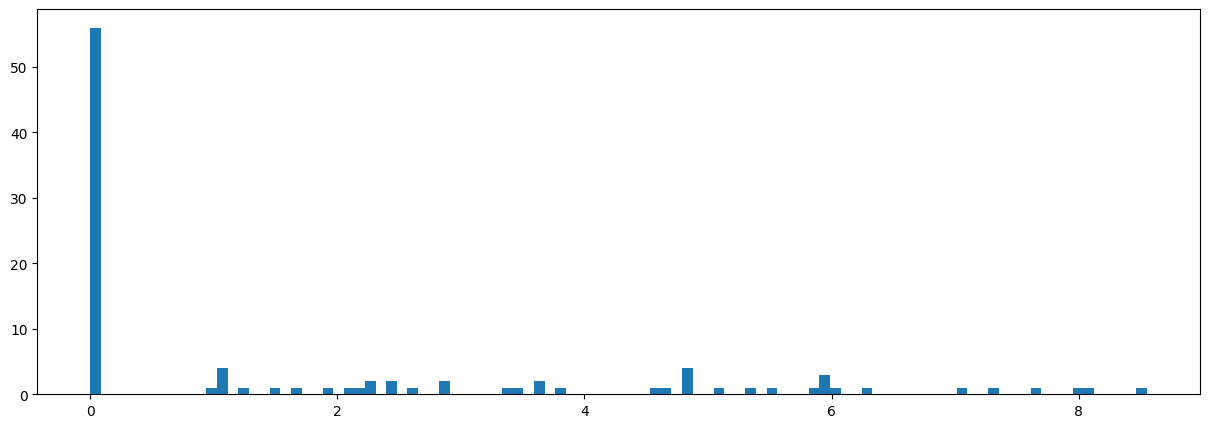

In [25]:
plt.figure(figsize=(15,5))
plt.hist(np.abs(clf.coefs_[1]).max(axis=1), bins=100)
plt.show()

Le pic a zéro représente neurones qui ont trois poids à zéros et donc n'influencent pratiquement pas la sortie. Le réseau a probablement appris que ce neurone n'était pas utile.

In [26]:
print((np.abs(clf.coefs_[1]).max(axis=1)>1).sum())


43


Sur les 100 neurones on en a que 43 qui un poids max d'au moins 1. Bien que ce soit un petit network, on peut voir qu'il n'utilise pas la plupart de ses neurones pour sa décision finale.

On peut également regarder quels neurones participent le plus à la décision  pour chaque classe : 

In [27]:
print(clf.coefs_[1].argmax(axis=0))
print(clf.coefs_[1].max(axis=0))

print(clf.coefs_[1].argmin(axis=0))
print(clf.coefs_[1].min(axis=0))

[14 37 33]
[8.02096967 5.0933528  5.01511544]
[20  8 63]
[-4.64131923 -7.02017337 -8.55326711]


0.0 2.6796251622005274


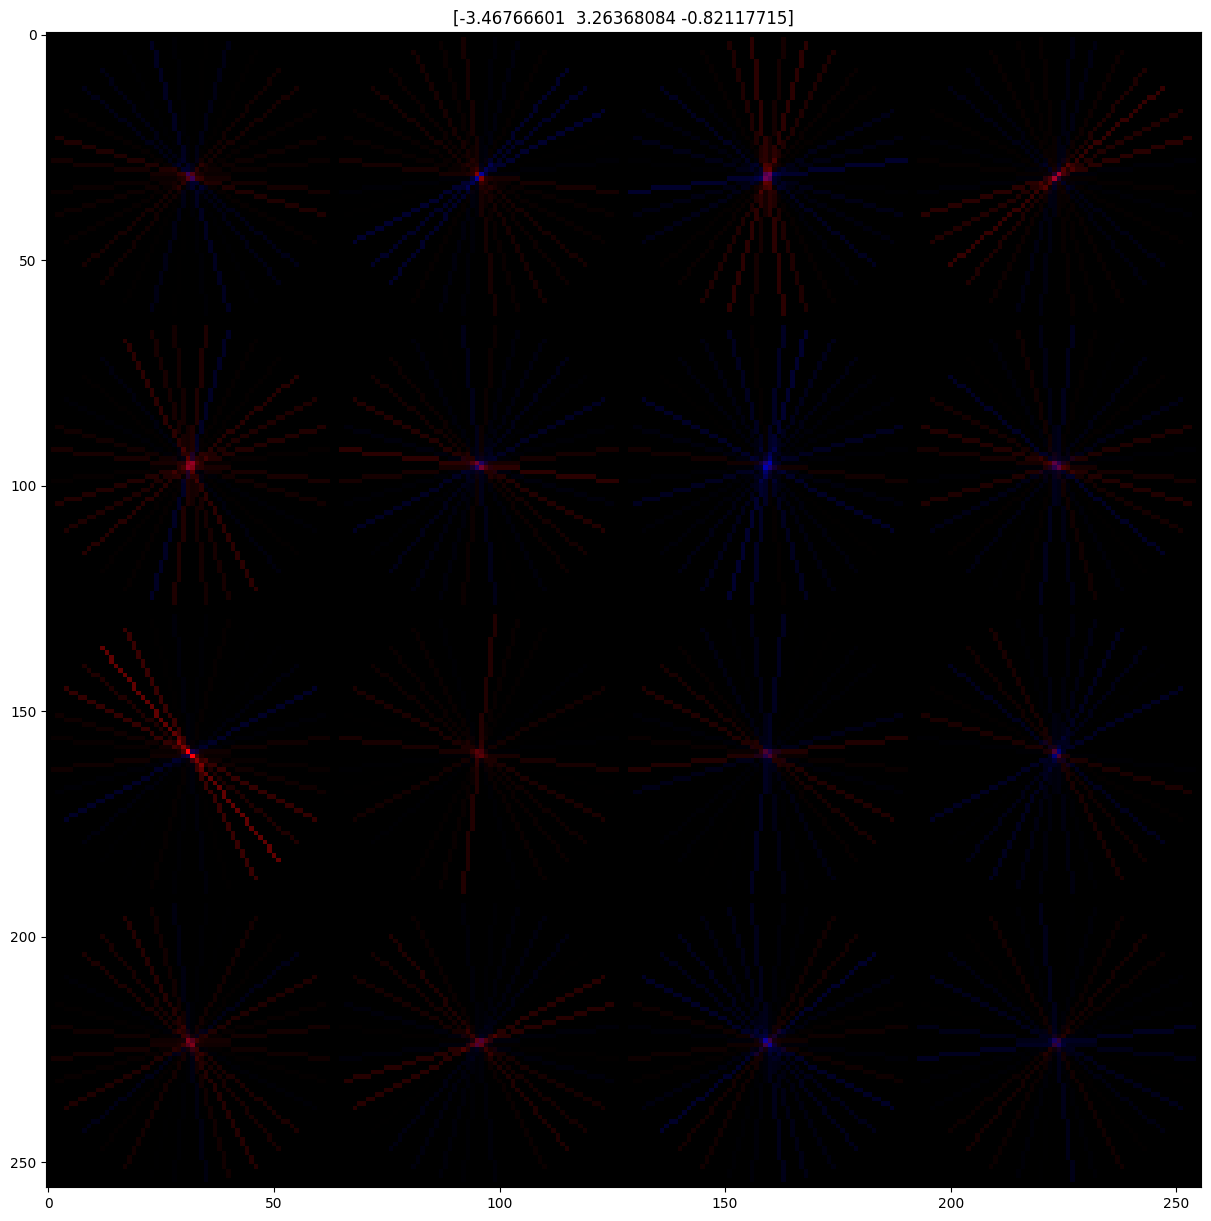

In [28]:
from lab_tools import get_hog_image
%matplotlib inline

i=2
hog = get_hog_image(clf.coefs_[0][:,i].reshape((4,4,-1)),output_size = 256)
print(hog.min(), hog.max())
plt.figure(figsize=(15,15))
plt.imshow(hog/hog.max())
plt.title(clf.coefs_[1][i])
plt.show()

## Add hidden layers to the network.

Try to change the structure of the network by adding hidden layers. Using cross-validation, try to find the best architecture for your network.

In [31]:
X_train_val = dataset.train["hog"]
Y_train_val = dataset.train["labels"]

X_test = dataset.test["hog"]
Y_test = dataset.test["labels"]

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        max_iter=500,
        random_state=0,
        early_stopping=True
    ))
])
param_grid = {
    "mlp__hidden_layer_sizes": [
        (20,),
        (50,),
        (100,),
        (50, 20),
        (100, 50)
    ],
    "mlp__alpha": [0.0001, 0.001, 0.01]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train_val, Y_train_val)

print("Best parameters:", grid.best_params_)
print(f"Best CV accuracy: {grid.best_score_:.4f}")

pred_test = grid.predict(X_test)

score_test = accuracy_score(Y_test, pred_test)
cm_test = confusion_matrix(Y_test, pred_test)

print(f"Test accuracy: {score_test:.4f}")
print("Confusion matrix:")
print(cm_test)

Best parameters: {'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (100,)}
Best CV accuracy: 0.7923
Test accuracy: 0.8043
Confusion matrix:
[[830 123  47]
 [123 747 130]
 [ 41 123 836]]
